## 単回帰分析

### 回帰式
```math
y = ax+b
```

### 準備

In [6]:
import pandas as pd

df = pd.read_csv('../data/simple_linear_data.csv')
display(df.head(3))
display(df.describe().T)

,x,y
0,3.745401,16.410298
1,9.507143,32.923414
2,7.319939,27.143340


,count,mean,std,min,25%,50%,75%,max
x,100.0,4.701807,2.974894,0.055221,1.932008,4.641425,7.302031,9.868869
y,100.0,19.103262,8.837473,4.517970,11.572464,18.021013,27.029385,36.170254


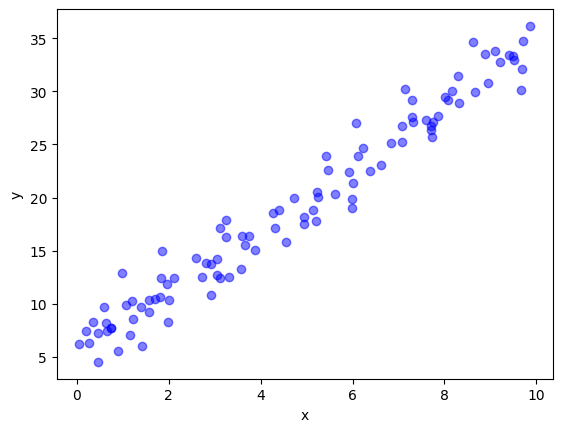

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["x"], df["y"], color="blue", alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### `scikit-learn`を利用したモデルの実装

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

X = df[["x"]]  # 2次元配列として取得
Y = df["y"]

lr.fit(X, Y)

print(f"傾き (a): {lr.coef_[0]:.4f}")
print(f"切片 (b): {lr.intercept_:.4f}")

傾き (a): 2.9080
切片 (b): 5.4302


### `pulp`を用いた実装

In [22]:
import pulp

model = pulp.LpProblem('Linear_Regression_LAD', pulp.LpMinimize)

# データを定数として取得（決定変数ではない！）
x_data = df["x"].values
y_data = df["y"].values
n = len(x_data)

# 決定変数の定義
a = pulp.LpVariable('a')
b = pulp.LpVariable('b')

# |y_i - (a*x_i + b)| を表すために補助変数 e_i を導入
# 
# 方法: e_i >= 残差 かつ e_i >= -残差 という制約を追加
#       e_i を最小化すると、e_i = |残差| が達成される
e = [pulp.LpVariable(f'e_{i}', lowBound=0) for i in range(n)]

# 目的関数
model += pulp.lpSum(e)

# 制約条件：絶対値の線形化
for i in range(n):
    residual = y_data[i] - (a * x_data[i] + b)  # x_data[i], y_data[i] は定数
    model += e[i] >= residual    # e_i >= 残差
    model += e[i] >= -residual   # e_i >= -残差

# 求解
model.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Status: {pulp.LpStatus[model.status]}")
print(f"傾き (a): {pulp.value(a):.4f}")
print(f"切片 (b): {pulp.value(b):.4f}")

Status: Optimal
傾き (a): 2.8756
切片 (b): 5.5850
